# Изменение UX по Create ad - DiD анализ

__Описание задачи__

_Заказчик:_ Product Manager

_Контекст:_ продуктовая команда подготовила гипотезы по улучшению флоу пользователей в части создания рекламы.
Ожидаемый эффект - улучшение конверсии в создание кампании и сокращение времени на создание кампании.

_Гипотезы:_

После нажатия на шаг "Create Ad" слать пользователя сразу в окно создания креатива, а не в раздел со списком креативов

Автоматически подставлять созданный креатив в РК при создании креатива внутри рк или при создании вне рк и переходе на создание РК

План продуктового тестирования:

Аудитория: все пользователи всех форматов (новые и старые), за исключением сегмента L (список дадут аналитики)
Деление на группы: по ад-нетворкам (через GTM)
Тритмент: Онклика
Контроль: Кликадилла
Метод анализа - pre-post DiD (Difference-in-differences)
Срок теста: 7 дней (предварительно)
Окно анализа: 21 день (7 дней до + 7 дней теста + 7 дней после). Результаты увидим спустя 16 дней с даты начала теста (2 дня закладываю на анализ)

1. Primary метрики:

- новые пользователи - конверсия из регистрации в создание кампании
- старые пользователи - конверсия из начала создания кампании в завершение

2. Secondary метрики:

- среднее время от начала создания кампании до завершения, в разрезе новый / старый клиент.
- медиана и перцентили (P75, P90)
- доля пользователей, которые изменяют авто-подставленный креатив перед запуском (покажет кому фича "стреляет в ногу")
- воронка по шагам Регистрация → попал в экран с 3 сценариями → нажал Create Ad / Create Campaign → создал кампанию. Тогда после теста будет проще понять, на каком шаге улучшение (например, снижает ли авто-подстановка креатива дроп на шаге выбора креатива)
- время от завершения создания креатива до старта кампании (это потом поможет лучше интерпретировать эффект гипотезы 2: мы ускоряем выбор креатива или весь флоу в целом)

_Бизнес-цель:_ подготовить код для последующего анализа АБ теста

_Задача_

Необходимо подготовить полный набор скриптов и расчётов для анализа продуктового теста по методу Difference-in-Differences (pre/post анализ), заменяющего ранее планировавшийся A/B-тест.

Скрипты должны быть написаны так, как будто тест уже прошёл — с возможностью выставить даты начала/окончания теста и автоматически пересчитать все метрики.

_Нужно:_

- Провести исторические расчёты (неделя):
- объёмы целевых флоу,
- конверсии новых/старых пользователей,
- разбивку воронки,
- времена создания кампаний,
- перцентили и стандартные отклонения.

Подготовить код для последующего анализа теста с группами Treatment (Онклика) и Control (Кликадилла), исключая сегмент L.

_Реализовать расчёты:_

- Primary метрик (конверсии новых и старых),
- Secondary (время, воронки, поведение с креативами)

Все расчёты должны быть выполнены в разрезе: pre / test / post + DID-эффект.

Скрипты должны позволять быстро адаптировать дату запуска и окна анализа

# Импорт и запросы

In [1]:
import os
import pandas as pd
import numpy as np
import sqlalchemy as sql
from sqlalchemy import create_engine
from math import ceil
from scipy.stats import norm
from datetime import datetime, timedelta
from typing import Dict
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
db_config = {
'host': 'dbro.clickadilla.com',
'port' : 3306,
'db' : 'clickadilla_db',
'user' : os.getenv('MYSQL_USER'),
'pass' : os.getenv('MYSQL_PASSWORD'),
}
 
# connection_string = "mysql+pymysql://<dbuser>:<pwd>@<server_ip>/<db_instance>"
connection_string = 'mysql+pymysql://{}:{}@{}/{}'.format(
    db_config['user'],
    db_config['pass'],
    db_config['host'],
    db_config['db'],
)

In [4]:
engine = create_engine(connection_string)

Задаём время теста

Функция для расчёта интервалов (для вставок в запросы)

In [5]:
def calc_did_weeks(last_day_str: str) -> Dict[str, Dict[str, str]]:
    """
    last_day_str: последний доступный день в формате 'YYYY-MM-DD'
    
    Возвращает словарь:
    {
        "pre":  {"start": "YYYY-MM-DD", "end": "YYYY-MM-DD"},
        "test": {"start": "YYYY-MM-DD", "end": "YYYY-MM-DD"},
        "post": {"start": "YYYY-MM-DD", "end": "YYYY-MM-DD"},
    }
    """
    last_day = datetime.strptime(last_day_str, "%Y-%m-%d").date()
    
    # post неделя
    post_end = last_day
    post_start = post_end - timedelta(days=6)

    # test неделя
    test_end = post_start - timedelta(days=1)
    test_start = test_end - timedelta(days=6)

    # pre неделя
    pre_end = test_start - timedelta(days=1)
    pre_start = pre_end - timedelta(days=6)

    windows = {
        "pre": {
            "start": pre_start.isoformat(),
            "end": pre_end.isoformat(),
        },
        "test": {
            "start": test_start.isoformat(),
            "end": test_end.isoformat(),
        },
        "post": {
            "start": post_start.isoformat(),
            "end": post_end.isoformat(),
        },
    }
    return windows

Задаём последний день

In [6]:
last_day = "2025-12-07"

Вставляем в функцию

In [7]:
windows = calc_did_weeks(last_day)

In [8]:
print('Интервалы теста')
windows

Интервалы теста


{'pre': {'start': '2025-11-17', 'end': '2025-11-23'},
 'test': {'start': '2025-11-24', 'end': '2025-11-30'},
 'post': {'start': '2025-12-01', 'end': '2025-12-07'}}

Достаём переменные (чтобы потом подставлять в SQL)

In [9]:
pre_start, pre_end = windows["pre"]["start"], windows["pre"]["end"]
test_start, test_end = windows["test"]["start"], windows["test"]["end"]
post_start, post_end = windows["post"]["start"], windows["post"]["end"]

global_start = pre_start
global_end = post_end

# Конверсия в создание кампании для новых юзеров

## Запрос для расчёта

Логика запроса

_1. Определяем окна анализа (pre / test / post)_

Мы заранее вычисляем три 7-дневных интервала относительно последнего доступного дня.
Эти интервалы нужны для классификации: в какую неделю попал новый пользователь.

_2. Формируем список API-пользователей (исключаем из анализа)_

CTE api_users:

- выбираем user_id всех пользователей, у которых хоть одна кампания создана с is_api_created = 1;
- эти пользователи исключаются из всех дальнейших расчётов;

таким образом мы считаем конверсию только для «нормальных» пользователей.

_3. Формируем когорту новых пользователей_

CTE cohort_users:

берём пользователей, у которых:

- created_at попадает в любое из окон pre/test/post;
- почта не служебная (NOT LIKE '%onlinesup%', %tubecorporate%');
- пользователь не входит в список api_users;
- пользователь не входит в таблицу networks (RTB);

считаем:

    - reg_date — дата регистрации,
    - network — сеть (ad_networks.name),
    - week_label — pre/test/post в зависимости от reg_date.

Это — наша когорта новых пользователей.

_4. Определяем, сделал ли новый пользователь хотя бы одну кампанию_

CTE cohort_user_conv:

Для каждого пользователя из когорты: джойним таблицу campaigns по user_id;

берём только кампании:

- is_api_created = 0 (только реальные кампании);
- created_at >= reg_date (кампания создана после регистрации);

считаем:

has_campaign = 1, если у пользователя есть хотя бы одна такая кампания, иначе 0.

Важно:
Один пользователь → одна строка → бинарная конверсия (0/1).
Количество кампаний не влияет.

_5. Агрегируем по дням и по сеткам_

CTE daily_cr агрегируем по:

- reg_date,
- network,
- week_label.

и считаем:

- new_users — сколько новых пользователей в этот день и сети,
- conv_users — сколько из них имеют has_campaign = 1.

_6. Итоговый выбор_

Возвращаем дневные данные:

- reg_date — когда пользователь пришёл,
- network — сеть,
- week_label — pre/test/post,
- new_users — сколько новых,
- conv_users — сколько создали кампанию.
- cr - conversion rate текущего дня

In [10]:
sql_cr_daily = f"""
WITH api_users AS (
    SELECT DISTINCT c.user_id
    FROM campaigns c
    WHERE c.is_api_created = 1
),

l_users AS (
SELECT p.user_id,
SUM(p.amount/10000) AS spend
FROM payments p
WHERE p.type IN ('marketplace', 'campaign')
AND p.created_at BETWEEN '{global_end}' - INTERVAL 30 DAY AND '{global_end}'
GROUP BY user_id
HAVING spend > 5000),

cohort_users AS (
    SELECT
        u.id AS user_id,
        DATE(u.created_at) AS reg_date,
        COALESCE(ad_networks.name, 'unknown') AS network,
        CASE
            WHEN DATE(u.created_at) BETWEEN '{pre_start}' AND '{pre_end}'
                THEN 'pre'
            WHEN DATE(u.created_at) BETWEEN '{test_start}' AND '{test_end}'
                THEN 'test'
            WHEN DATE(u.created_at) BETWEEN '{post_start}' AND '{post_end}'
                THEN 'post'
            ELSE 'outside'
        END AS week_label
    FROM users AS u
    LEFT JOIN ad_networks
        ON u.ad_network_id = ad_networks.id
    WHERE DATE(u.created_at) BETWEEN '{global_start}' AND '{global_end}'
      AND u.email NOT LIKE '%%@onlinesup.com'
      AND u.email NOT LIKE '%%@tubecorporate.com'
      AND u.id NOT IN (SELECT user_id FROM api_users)        -- ❗ исключаем всех с API-кампаниями
      AND u.id NOT IN (SELECT DISTINCT user_id FROM networks)
      AND u.id NOT IN (SELECT DISTINCT user_id FROM l_users)
      AND u.ad_network_id IN (1, 4)
),

cohort_user_conv AS (
    SELECT
        cu.user_id,
        cu.reg_date,
        cu.network,
        cu.week_label,
        CASE
            WHEN COUNT(c.id) > 0 THEN 1
            ELSE 0
        END AS has_campaign
    FROM cohort_users cu
    LEFT JOIN campaigns c
        ON c.user_id = cu.user_id
       AND c.is_api_created = 0                          -- считаем только НЕ api-кампании для конверсии
       AND DATE(c.created_at) >= cu.reg_date             -- кампания после регистрации
    WHERE cu.week_label IN ('pre', 'test', 'post')
    GROUP BY
        cu.user_id,
        cu.reg_date,
        cu.network,
        cu.week_label
),

daily_cr AS (
    SELECT
        reg_date,
        network,
        week_label,
        COUNT(*) AS new_users,
        SUM(has_campaign) AS conv_users
    FROM cohort_user_conv
    GROUP BY
        reg_date,
        network,
        week_label
)

SELECT
    reg_date,
    network,
    week_label,
    new_users,
    conv_users,
    conv_users / new_users AS cr
FROM daily_cr
ORDER BY reg_date, network;
"""

In [11]:
df_cr_daily = pd.read_sql(sql_cr_daily, engine)

In [12]:
df_cr_daily.head()

,reg_date,network,week_label,new_users,conv_users,cr
0,2025-11-17,Clickadilla,pre,22,1.0,0.0455
1,2025-11-17,Onclicka,pre,24,3.0,0.1250
2,2025-11-18,Clickadilla,pre,43,9.0,0.2093
3,2025-11-18,Onclicka,pre,26,3.0,0.1154
4,2025-11-19,Clickadilla,pre,28,10.0,0.3571


In [13]:
df_cr_daily['cr'].describe()

count    42.000000
mean      0.098940
std       0.082692
min       0.000000
25%       0.038175
50%       0.057550
75%       0.166700
max       0.357100
Name: cr, dtype: float64

Данные корректны

## Недельная конверсия + доверительный интервал

In [14]:
weekly = (
    df_cr_daily
    .groupby(["network", "week_label"], as_index=False)
    .agg(
        new_users_tot=("new_users", "sum"),
        conv_users_tot=("conv_users", "sum")
    )
)

# Фактическая недельная конверсия
weekly["cr"] = weekly["conv_users_tot"] / weekly["new_users_tot"]

# Стандартная ошибка и доверительный интервал (95%)
z = 1.96
weekly["se"] = np.sqrt(weekly["cr"] * (1 - weekly["cr"]) / weekly["new_users_tot"])
weekly["cr_ci_low"] = weekly["cr"] - z * weekly["se"]
weekly["cr_ci_high"] = weekly["cr"] + z * weekly["se"]

weekly["cr_ci_low"] = weekly["cr_ci_low"].clip(lower=0)
weekly["cr_ci_high"] = weekly["cr_ci_high"].clip(upper=1)

In [15]:
weekly.round(3)

,network,week_label,new_users_tot,conv_users_tot,cr,se,cr_ci_low,cr_ci_high
0,Clickadilla,post,823,32.0,0.039,0.007,0.026,0.052
1,Clickadilla,pre,202,40.0,0.198,0.028,0.143,0.253
2,Clickadilla,test,1117,24.0,0.021,0.004,0.013,0.030
3,Onclicka,post,134,8.0,0.060,0.020,0.020,0.100
4,Onclicka,pre,186,16.0,0.086,0.021,0.046,0.126
5,Onclicka,test,166,12.0,0.072,0.020,0.033,0.112


## Статистика по дневным CR + MDE

Средний CR по всей выборке,

Стандартное отклонение CR по всей выборке,

Медиана количества пользователей за неделю

In [22]:
cr_mean_all = df_cr_daily["cr"].mean()
cr_std_all = df_cr_daily["cr"].std(ddof=1)

In [23]:
print(f'Среднее по выборке', round(cr_mean_all, 3))
print(f'Стандартное отклонение по выборке', round(cr_std_all, 3))

Среднее по выборке 0.099
Стандартное отклонение по выборке 0.083


Доверительный интервал общий

In [28]:
cr_all = df_cr_daily['cr'].dropna()

In [19]:
n = cr_all.shape[0]
mean = cr_all.mean()
std = cr_all.std(ddof=1) 
se  = std / np.sqrt(n) 

In [20]:
ci_low  = mean - z * se
ci_high = mean + z * se

In [21]:
print('Нижняя и верхняя граница CI для дневного CR')
print(round(ci_low, 3)) 
print(round(ci_high, 3))

Нижняя и верхняя граница CI для дневного CR
0.074
0.124


In [24]:
median_users_weekly = (
    df_cr_daily
    .groupby(["week_label", "network"], as_index=False)
    .agg(
        new_users_week=("new_users", "sum")
    )
)['new_users_week'].median()

In [25]:
print(f'Медиана количества рег за неделю', median_users_weekly)

Медиана количества рег за неделю 194.0


Формула МДЕ
$$
\text{MDE}_{abs}
=
\left( z_{\alpha/2} + z_{\beta} \right)
\cdot
\sigma
\sqrt{\frac{2}{n}}
$$

In [26]:
# Параметры теста
alpha = 0.05
power = 0.8

z_alpha_2 = 1.96  # alpha = 0.05
z_beta = 0.84     # power = 0.8
z_sum = z_alpha_2 + z_beta

sigma = cr_std_all                # стандартное отклонение CR по всей выборке
cr_baseline = cr_mean_all     # базовый CR из исторических данных
median_weekly_n = median_users_weekly  # медианный weekly размер выборки на группу

rows = []
for weeks in [1, 2, 3, 4]:
    n_per_arm = median_weekly_n * weeks  # размер выборки в каждой группе
    se_diff = sigma * np.sqrt(2 / n_per_arm)
    mde_abs = z_sum * se_diff
    mde_rel = mde_abs / cr_baseline

    rows.append({
        "weeks": weeks,
        "n_per_arm": int(round(n_per_arm)),
        "n_total_two_arms": int(round(2 * n_per_arm)),
        "baseline_cr": cr_baseline,
        "mde_abs": mde_abs,
        "mde_rel": mde_rel,
    })

df_mde = pd.DataFrame(rows)

In [27]:
df_mde_display = df_mde.copy()

df_mde_display["baseline_cr_%"] = (df_mde_display["baseline_cr"] * 100).round(2)
df_mde_display["mde_abs_%"] = (df_mde_display["mde_abs"] * 100).round(2)
df_mde_display["mde_rel_%"] = (df_mde_display["mde_rel"] * 100).round(2)

df_mde_display[[
    "weeks",
    "n_per_arm",
    "n_total_two_arms",
    "baseline_cr_%",
    "mde_abs_%",
    "mde_rel_%"
]]

,weeks,n_per_arm,n_total_two_arms,baseline_cr_%,mde_abs_%,mde_rel_%
0,1,194,388,9.89,2.35,23.76
1,2,388,776,9.89,1.66,16.80
2,3,582,1164,9.89,1.36,13.72
3,4,776,1552,9.89,1.18,11.88


Для недельного теста МДЕ = 24.8% или 2.27 п.п. (Ожидаемое увеличение конверсии)

## DiD анализ

In [29]:
treatment_name = "Onclicka"
control_name = "Clickadilla"

In [30]:
cr_pivot = (
    weekly
    .pivot(
        index="network",
        columns="week_label",
        values="cr"
    )
    .loc[[treatment_name, control_name], ["pre", "test", "post"]]
)

cr_pivot.round(3)

week_label,pre,test,post
network,,,
Onclicka,0.086,0.072,0.060
Clickadilla,0.198,0.021,0.039


In [31]:
cr_T_pre  = cr_pivot.loc[treatment_name, "pre"]
cr_T_test = cr_pivot.loc[treatment_name, "test"]
cr_T_post = cr_pivot.loc[treatment_name, "post"]

cr_C_pre  = cr_pivot.loc[control_name, "pre"]
cr_C_test = cr_pivot.loc[control_name, "test"]
cr_C_post = cr_pivot.loc[control_name, "post"]

# изменения в тест и пост относительно pre
delta_T_test = cr_T_test - cr_T_pre
delta_T_post = cr_T_post - cr_T_pre

delta_C_test = cr_C_test - cr_C_pre
delta_C_post = cr_C_post - cr_C_pre

# DiD-эффекты
did_test = delta_T_test - delta_C_test
did_post = delta_T_post - delta_C_post

In [32]:
did_summary = pd.DataFrame({
    "group": ["treatment (Onclicka)", "control (Clickadilla)"],
    "CR_pre":  [cr_T_pre,  cr_C_pre],
    "CR_test": [cr_T_test, cr_C_test],
    "CR_post": [cr_T_post, cr_C_post],
    "Δ_test":  [delta_T_test, delta_C_test],
    "Δ_post":  [delta_T_post, delta_C_post],
})

did_effects = pd.DataFrame({
    "metric": ["did_test", "did_post"],
    "value":  [did_test, did_post],
})

In [33]:
did_summary.round(3)

,group,CR_pre,CR_test,CR_post,Δ_test,Δ_post
0,treatment (Onclicka),0.086,0.072,0.060,-0.014,-0.026
1,control (Clickadilla),0.198,0.021,0.039,-0.177,-0.159


In [34]:
did_effects.round(3)

,metric,value
0,did_test,0.163
1,did_post,0.133


__Краткая интерпретация результатов DiD (что показывает таблица)__

1. Каждая группа (тест и контроль) имеет свою конверсию в три периода:

- до теста (pre),
- в тестовую неделю (test),
- после теста (post).

2. Для каждой группы считаем, как изменилась конверсия относительно pre:

Во время теста
$$
\Delta^{g}_{test} = CR_{g,\text{test}} - CR_{g,\text{pre}}
$$
После теста
$$
\Delta^{g}_{post} = CR_{g,\text{post}} - CR_{g,\text{pre}}
$$

3. DiD-эффект показывает, насколько по-разному изменились тест и контроль:

если контроль сильно ухудшился, а тест упал меньше — DiD будет положительным;

если тест ухудшился сильнее, чем контроль — DiD будет отрицательным.

Как это интерпретировать в общем виде:

Положительное Δ означает, что тестовая группа показала себя лучше, чем можно было ожидать исходя из поведения контроля.

Отрицательное Δ означает, что тестовая группа ухудшилась сильнее, чем контроль.

Важный момент: DiD учитывает общие тренды (сезонность, сбои спроса), поэтому он показывает чистый эффект теста, очищенный от внешних факторов.

Таблица, которую мы получили, фактически отвечает на три вопроса:

1. Как изменилась конверсия в тесте и в контроле?

Показывают столбцы Δ_test, Δ_post.

2. Какова разница изменений между тестом и контролем?

Показывают строки did_test, did_post.

3. “Выиграл” тест или “проиграл”?

Определяется знаком и величиной Δ:

Δ > 0 → тестовая группа удержалась лучше, чем контроль → потенциальный положительный эффект.

Δ < 0 → тест ухудшился относительно контроля → негативный эффект.

## Итог А-А теста

У нас did_test = 0.158 , did_post = 0.131, при этом МДЕ для недельного теста = 2.27 (или 25%). А мы получили эффект в 15.8 или 196%, по факту проведя А-А тест на исторических данных. Говорит ли это о том, что тест некорректен и где мы могли ошибиться?

Коротко: у нас всё “по-честному”, и как раз поэтому видно, что такой тестовый дизайн плохой.
Это не ошибка в коде, это сигнал, что сетки не могут быть чистым А/В-сплитом.

__Почему “А–А” даёт огромный эффект__

Фактически мы сделали не A–A внутри одной популяции, а сравнение двух разных сетей с разными трендами во времени:

- у теста и контроля разные baseline CR (pre сильно отличается),
- у них по-разному ведёт себя конверсия во времени (контроль проседает намного сильнее),

DiD это честно подсвечивает как “эффект”.

Это как сделать “А–А-тест”, сравнивая:

- одну страну, где рынок рухнул,
- и другую, где всё почти стабильно.

Естественно, DiD покажет огромный τ, хотя фичи нет. Это не баг, это сигнал:

У сетей нет параллельных трендов, поэтому одна сеть не годится в качестве «чистого» контроля для другой.

__Значит ли это, что тест “некорректен” и где могли ошибиться?__

Скорее так:

Дизайн “Onclicka vs Clickadilla как тест/контроль” некорректен
для причинной оценки эффекта фичи. Нарушена ключевая предпосылка DiD:
“при отсутствии воздействия тренды в тесте и контроле были бы параллельны”.

MDE, который мы посчитали, относится к другой задаче
(простой A/B для CR) и в другую сторону не проверяет корректность DiD.

В коде/SQL вероятная логика выглядит здраво:

- когорты по датам,
- фильтры по почтам / API / networks,
- 0/1-конверсия на пользователя,
- группировка по неделям и сетям.

То есть “ошибка” не в синтаксисе, а именно в выборе групп как А/В.

Что с этим делать дальше

Если цель — реальный эксперимент:

- сплит нужно делать внутри одной сети, например по пользователям:
- чёт/нечёт user_id, случайный hash-сплит и т.п.;
- сети (Onclicka / Clickadilla) лучше использовать как страты, а не как сами группы теста.

Если цель — остаться в DiD, то:

- добавлять больше pre-периодов и явно проверять параллельность трендов (график CRtest И CRcontrol по времени)
- либо использовать более стабильный контроль (например, сплит внутри той же сети).

# Конверсия в создание кампании для старых юзеров

## Проверка работы хранилища BQ (не выполнять при переиспользовании)

### Запрос в MySQL для выборки пользователей

Тестовая версия

In [34]:
query = f"""
SELECT
    c.id           AS campaign_id,
    c.user_id,
    c.created_at   AS campaign_created_at,
    an.name        AS ad_network_name
FROM campaigns c
JOIN users u
    ON u.id = c.user_id
LEFT JOIN networks n
    ON n.user_id = u.id
JOIN ad_networks an
    ON an.id = u.ad_network_id
WHERE
    u.created_at < '{global_start}'

    AND u.email NOT LIKE '%%onlinesup%%'
    AND u.email NOT LIKE '%%tubecorporate%%'

    AND n.user_id IS NULL

    AND NOT EXISTS (
        SELECT 1
        FROM campaigns c_api
        WHERE c_api.user_id = u.id
          AND c_api.is_api_created = 1
    )

    AND c.is_api_created = 0

    AND c.created_at >= '{global_start}'
    AND c.created_at <  '{global_end}'

ORDER BY c.user_id DESC, c.created_at DESC
LIMIT 500
"""

In [35]:
df_old_campaigns = pd.read_sql(query, engine)

In [36]:
df_old_campaigns.head(10)

,campaign_id,user_id,campaign_created_at,ad_network_name
0,477909,211379,2025-12-04 16:19:32,Clickadilla
1,473032,211379,2025-11-17 00:14:39,Clickadilla
2,476625,211360,2025-11-29 16:41:39,Clickadilla
3,476623,211360,2025-11-29 16:34:12,Clickadilla
4,474709,211341,2025-11-22 09:26:16,Onclicka
5,473809,211341,2025-11-19 18:12:13,Onclicka
6,473547,211341,2025-11-19 08:58:46,Onclicka
7,473314,211341,2025-11-18 09:41:05,Onclicka
8,473167,211341,2025-11-17 13:40:49,Onclicka
9,473163,211341,2025-11-17 13:00:16,Onclicka


### Запрос в BQ

In [37]:
query = '''

WITH onclicka_events AS (
  SELECT
    up.value.int_value AS user_id,
    TIMESTAMP_MICROS(e.event_timestamp) AS event_ts,
    e.event_name,
    'onclicka' AS network,
    CASE
      WHEN e.event_name = 'start_create_campaign' THEN 'start'
      WHEN e.event_name = 'campaign_created_successfully' THEN 'finish'
    END AS funnel_step
  FROM `clickadilla.analytics_375634261.events_*` AS e
  CROSS JOIN UNNEST(e.user_properties) AS up
  WHERE
    e._TABLE_SUFFIX BETWEEN '20251117' AND '20251207'
    AND TIMESTAMP_MICROS(e.event_timestamp) >= TIMESTAMP('2025-11-17 00:00:00 UTC')
    AND TIMESTAMP_MICROS(e.event_timestamp) <  TIMESTAMP('2025-12-08 00:00:00 UTC')
    AND up.key = 'userId'
    AND up.value.int_value IN (211379, 211360, 211341) -- 
    AND e.event_name IN (
      'start_create_campaign',
      'campaign_created_successfully'
    )
),

clickadilla_events AS (
  SELECT
    up.value.int_value AS user_id,
    TIMESTAMP_MICROS(e.event_timestamp) AS event_ts,
    e.event_name,
    'clickadilla' AS network,
    CASE
      WHEN e.event_name = 'create_campaign_1step' THEN 'start'
      WHEN e.event_name = 'create_campaign' THEN 'finish'
    END AS funnel_step
  FROM `clickadilla.analytics_243906903.events_*` AS e
  CROSS JOIN UNNEST(e.user_properties) AS up
  WHERE
    e._TABLE_SUFFIX BETWEEN '20251117' AND '20251207'
    AND TIMESTAMP_MICROS(e.event_timestamp) >= TIMESTAMP('2025-11-17 00:00:00 UTC')
    AND TIMESTAMP_MICROS(e.event_timestamp) <  TIMESTAMP('2025-12-08 00:00:00 UTC')
    AND up.key = 'userId'
    AND up.value.int_value IN (211379, 211360, 211341)
    AND e.event_name IN (
      'create_campaign_1step',
      'create_campaign'
    )
)

SELECT
  user_id,
  network,
  event_ts,
  event_name,
  funnel_step
FROM onclicka_events

UNION ALL

SELECT
  user_id,
  network,
  event_ts,
  event_name,
  funnel_step
FROM clickadilla_events

ORDER BY
  user_id,
  network,
  event_ts,
  event_name
'''

In [38]:
bqdata = pd.read_csv('bqdata.csv')

In [39]:
bqdata.head()

,user_id,network,event_ts,event_name,funnel_step
0,211341,onclicka,2025-11-17 08:59:22.702461 UTC,start_create_campaign,start
1,211341,onclicka,2025-11-17 09:02:16.004461 UTC,campaign_created_successfully,finish
2,211341,onclicka,2025-11-17 09:18:18.216355 UTC,start_create_campaign,start
3,211341,onclicka,2025-11-17 09:19:15.817441 UTC,campaign_created_successfully,finish
4,211341,onclicka,2025-11-17 10:08:20.394337 UTC,start_create_campaign,start


### Дебаг

Подготовим данные по MySQL (только нужные юзеры)

In [40]:
debug_users = [211379, 211360, 211341]

In [41]:
mysql = df_old_campaigns.copy()

переименуем в network

In [42]:
if 'ad_network_name' in mysql.columns and 'network' not in mysql.columns:
    mysql = mysql.rename(columns={'ad_network_name': 'network'})

In [43]:
mysql = mysql[mysql['user_id'].isin(debug_users)].copy()

In [44]:
mysql.head(10)

,campaign_id,user_id,campaign_created_at,network
0,477909,211379,2025-12-04 16:19:32,Clickadilla
1,473032,211379,2025-11-17 00:14:39,Clickadilla
2,476625,211360,2025-11-29 16:41:39,Clickadilla
3,476623,211360,2025-11-29 16:34:12,Clickadilla
4,474709,211341,2025-11-22 09:26:16,Onclicka
5,473809,211341,2025-11-19 18:12:13,Onclicka
6,473547,211341,2025-11-19 08:58:46,Onclicka
7,473314,211341,2025-11-18 09:41:05,Onclicka
8,473167,211341,2025-11-17 13:40:49,Onclicka
9,473163,211341,2025-11-17 13:00:16,Onclicka


In [45]:
bq = bqdata.copy()

Приводим к datetime64[ns]: интерпретируем как UTC и убираем tz

In [46]:
bq['event_ts'] = (
    pd.to_datetime(bq['event_ts'], utc=True, errors='coerce')
      .dt.tz_localize(None)
)

In [47]:
bq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      40 non-null     int64         
 1   network      40 non-null     object        
 2   event_ts     40 non-null     datetime64[ns]
 3   event_name   40 non-null     object        
 4   funnel_step  40 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 1.7+ KB


теперь сравним кол-во созданных кампаний в Кликадилла ДБ и BQ

In [48]:
print('MySQL campaigns')
(
    mysql
    .groupby(['user_id', 'network'], as_index=False)
    .agg(mysql_campaigns=('campaign_id', 'nunique'))
)

MySQL campaigns


,user_id,network,mysql_campaigns
0,211341,Onclicka,10
1,211360,Clickadilla,2
2,211379,Clickadilla,2


In [49]:
print('BQ campaigns')
(bq.query('funnel_step == "finish"').groupby(['user_id', 'network'], as_index=False)
    .agg(bq_finish_events=('event_name', 'count')))

BQ campaigns


,user_id,network,bq_finish_events
0,211341,onclicka,10
1,211360,clickadilla,2
2,211379,clickadilla,1


Видим одну потерю на 15 кампаний, в целом неплохо

Теперь сравним дельту по времени ивентов

In [50]:
mysql_match = (
    mysql[['user_id', 'network', 'campaign_id', 'campaign_created_at']]
    .dropna(subset=['campaign_created_at'])
    .sort_values(['user_id', 'network', 'campaign_created_at'])
    .rename(columns={'campaign_created_at': 'campaign_ts'}).reset_index(drop=True)
)

In [51]:
mysql_match['network'] = mysql_match['network'].str.lower()

In [52]:
bq_match = (
    bq.query('funnel_step == "finish"')
    .dropna(subset=['event_ts'])
    .sort_values(['user_id', 'network', 'event_ts']).reset_index(drop=True)
)

In [53]:
mysql_match['campaign_ts'] = mysql_match['campaign_ts'].dt.floor('S')
bq_match['event_ts'] = bq_match['event_ts'].dt.floor('S')

D:\Users\aleksandr.radionov\AppData\Local\Temp\1\ipykernel_7972\157794875.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  mysql_match['campaign_ts'] = mysql_match['campaign_ts'].dt.floor('S')
D:\Users\aleksandr.radionov\AppData\Local\Temp\1\ipykernel_7972\157794875.py:2: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  bq_match['event_ts'] = bq_match['event_ts'].dt.floor('S')


In [54]:
mysql_match = (
    mysql_match
    .sort_values(['user_id', 'network', 'campaign_ts'])
    .reset_index(drop=True)
)

bq_match = (
    bq_match
    .sort_values(['user_id', 'network', 'event_ts'])
    .reset_index(drop=True)
)

считаем дельту времени через обычный merge

In [55]:
tmp = mysql_match.merge(
    bq_match,
    on=['user_id', 'network'],
    how='left',
    suffixes=('_mysql', '_bq')
)

In [56]:
tmp['delta_sec'] = (tmp['campaign_ts'] - tmp['event_ts']).dt.total_seconds().abs()

для каждой кампании выбираем ивент с минимальной дельтой

In [57]:
idx = (
    tmp
    .groupby(['user_id', 'network', 'campaign_id'])['delta_sec']
    .idxmin()
)

In [58]:
matched = tmp.loc[idx].copy()

In [59]:
matched['has_bq_finish'] = matched['event_ts'].notna()

In [60]:
print("Сколько кампаний имеют хотя бы один finish-ивент в BQ (по ближайшему):")
print(matched['has_bq_finish'].value_counts())

Сколько кампаний имеют хотя бы один finish-ивент в BQ (по ближайшему):
has_bq_finish
True    14
Name: count, dtype: int64


In [62]:
print("\nРаспределение |delta| в секундах по заматченным кампаниям:")
display(matched[matched['has_bq_finish']]['delta_sec'].describe().round())


Распределение |delta| в секундах по заматченным кампаниям:


count         14.0
mean      109054.0
std       408025.0
min            1.0
25%            6.0
50%            6.0
75%            6.0
max      1526694.0
Name: delta_sec, dtype: float64

In [63]:
matched[matched['has_bq_finish']]

,user_id,network,campaign_id,campaign_ts,event_ts,event_name,funnel_step,delta_sec,has_bq_finish
0,211341,onclicka,473088,2025-11-17 09:02:10,2025-11-17 09:02:16,campaign_created_successfully,finish,6.0,True
11,211341,onclicka,473091,2025-11-17 09:19:09,2025-11-17 09:19:15,campaign_created_successfully,finish,6.0,True
22,211341,onclicka,473127,2025-11-17 10:34:01,2025-11-17 10:34:07,campaign_created_successfully,finish,6.0,True
33,211341,onclicka,473138,2025-11-17 10:54:41,2025-11-17 10:54:47,campaign_created_successfully,finish,6.0,True
44,211341,onclicka,473163,2025-11-17 13:00:16,2025-11-17 13:00:22,campaign_created_successfully,finish,6.0,True
55,211341,onclicka,473167,2025-11-17 13:40:49,2025-11-17 13:40:55,campaign_created_successfully,finish,6.0,True
66,211341,onclicka,473314,2025-11-18 09:41:05,2025-11-18 09:41:11,campaign_created_successfully,finish,6.0,True
77,211341,onclicka,473547,2025-11-19 08:58:46,2025-11-19 08:58:52,campaign_created_successfully,finish,6.0,True
88,211341,onclicka,473809,2025-11-19 18:12:13,2025-11-19 18:12:19,campaign_created_successfully,finish,6.0,True
99,211341,onclicka,474709,2025-11-22 09:26:16,2025-11-22 09:26:22,campaign_created_successfully,finish,6.0,True


На Онклике ивент отрабатывает в основном через 6 секунд, на Кликадиле через 1-2 секунды, но видим и один выброс (строка 104)

На данном шаге это не критично, но будем держать это ввиду

Так же нами обнаружено, что ивент для старта создания кампании может отрабатывать несколько раз в течении небольшого промежутка времени (перед успешным созданием кампании). 

Предполагается, что это нам и нужно, в том смысле что конверсия в таких случаях будет (если ивент отработал два раза а кампания создана одна) равна 50%.

Эту логику необходимо согласовать/доработать. (Есть предложение считать ивенты только за X времени от старта до следующего старта. Х здесь может быть - 30 минут (одна сессия), среднее время создания кампании). То есть если мы имеем два ивента с разницей в одну минуту, трактовать это как один ивент?

## Полные запросы

### MySQL (Clickadilla DB)

In [37]:
query1 = f"""
SELECT
    c.id           AS campaign_id,
    c.user_id,
    c.created_at   AS campaign_created_at,
    an.name        AS ad_network_name
FROM campaigns c
JOIN users u
    ON u.id = c.user_id
LEFT JOIN networks n
    ON n.user_id = u.id
JOIN ad_networks an
    ON an.id = u.ad_network_id
WHERE
    u.created_at < '{global_start}'

    AND u.email NOT LIKE '%%onlinesup%%'
    AND u.email NOT LIKE '%%tubecorporate%%'

    AND n.user_id IS NULL

    AND NOT EXISTS (
        SELECT 1
        FROM campaigns c_api
        WHERE c_api.user_id = u.id
          AND c_api.is_api_created = 1
    )

    AND c.is_api_created = 0
AND c.user_id NOT IN (SELECT DISTINCT user_id FROM (
SELECT p.user_id,
SUM(p.amount/10000) AS spend
FROM payments p
WHERE p.type IN ('marketplace', 'campaign')
AND p.created_at BETWEEN '{global_end}' - INTERVAL 30 DAY AND '{global_end}'
GROUP BY user_id
HAVING spend > 5000) AS p)
    AND c.created_at >= '{global_start}'
    AND c.created_at <  '{global_end}'

ORDER BY c.user_id DESC, c.created_at DESC
"""

In [38]:
df_old = pd.read_sql(query1, engine)

In [39]:
df_old.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3612 entries, 0 to 3611
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   campaign_id          3612 non-null   int64         
 1   user_id              3612 non-null   int64         
 2   campaign_created_at  3612 non-null   datetime64[ns]
 3   ad_network_name      3612 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 113.0+ KB


In [40]:
df_old['ad_network_name'].value_counts()

ad_network_name
Clickadilla    3073
Onclicka        539
Name: count, dtype: int64

Видим дисбаланс по создаваемым кампаниям между нетворками

In [41]:
df_old.groupby('user_id')['campaign_id'].nunique().reset_index().sort_values(by='campaign_id', 
                                                                             ascending=False)

,user_id,campaign_id
159,182441,783
43,34724,518
193,197202,370
253,210298,231
32,29272,191
...,...,...
214,202012,1
102,119752,1
211,200943,1
209,199942,1


Так же видим юзеров с большим кол-вом создаваемых кампаний. Предположительно, с ними нужно будет работать при интерпретации результатов теста

In [42]:
df_old.agg({'campaign_created_at':['min', 'max']})

,campaign_created_at
min,2025-11-17 00:14:39
max,2025-12-06 23:58:00


Даты корректны

In [43]:
df_old['user_id'].nunique()

290

290 юзеров в выборке

### BQ

In [72]:
querybq = '''

WITH onclicka_events AS (
  SELECT
    up.value.int_value AS user_id,
    TIMESTAMP_MICROS(e.event_timestamp) AS event_ts,
    e.event_name,
    'onclicka' AS network,
    CASE
      WHEN e.event_name = 'start_create_campaign' THEN 'start'
      WHEN e.event_name = 'campaign_created_successfully' THEN 'finish'
    END AS funnel_step
  FROM `clickadilla.analytics_375634261.events_*` AS e
  CROSS JOIN UNNEST(e.user_properties) AS up
  WHERE
    e._TABLE_SUFFIX BETWEEN '20251117' AND '20251207'
    AND TIMESTAMP_MICROS(e.event_timestamp) >= TIMESTAMP('2025-11-17 00:00:00 UTC')
    AND TIMESTAMP_MICROS(e.event_timestamp) <  TIMESTAMP('2025-12-08 00:00:00 UTC')
    AND up.key = 'userId'
    AND e.event_name IN (
      'start_create_campaign',
      'campaign_created_successfully'
    )
),

clickadilla_events AS (
  SELECT
    up.value.int_value AS user_id,
    TIMESTAMP_MICROS(e.event_timestamp) AS event_ts,
    e.event_name,
    'clickadilla' AS network,
    CASE
      WHEN e.event_name = 'create_campaign_1step' THEN 'start'
      WHEN e.event_name = 'create_campaign' THEN 'finish'
    END AS funnel_step
  FROM `clickadilla.analytics_243906903.events_*` AS e
  CROSS JOIN UNNEST(e.user_properties) AS up
  WHERE
    e._TABLE_SUFFIX BETWEEN '20251117' AND '20251207'
    AND TIMESTAMP_MICROS(e.event_timestamp) >= TIMESTAMP('2025-11-17 00:00:00 UTC')
    AND TIMESTAMP_MICROS(e.event_timestamp) <  TIMESTAMP('2025-12-08 00:00:00 UTC')
    AND up.key = 'userId'
    AND e.event_name IN (
      'create_campaign_1step',
      'create_campaign'
    )
)

SELECT
  user_id,
  network,
  event_ts,
  event_name,
  funnel_step
FROM onclicka_events

UNION ALL

SELECT
  user_id,
  network,
  event_ts,
  event_name,
  funnel_step
FROM clickadilla_events

ORDER BY
  user_id,
  network,
  event_ts,
  event_name
'''

In [44]:
bqlarge = pd.read_csv('bqlarge.csv')

In [45]:
bqlarge.head()

,user_id,network,event_ts,event_name,funnel_step
0,NaN,clickadilla,2025-11-25 08:54:28.815403 UTC,create_campaign_1step,start
1,496.0,clickadilla,2025-11-21 22:16:37.957458 UTC,create_campaign_1step,start
2,496.0,clickadilla,2025-11-21 22:17:36.703938 UTC,create_campaign,finish
3,1427.0,clickadilla,2025-12-06 23:57:58.794888 UTC,create_campaign_1step,start
4,1427.0,clickadilla,2025-12-07 00:33:41.814901 UTC,create_campaign,finish


In [46]:
bqlarge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8891 entries, 0 to 8890
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   user_id      8890 non-null   float64
 1   network      8891 non-null   object 
 2   event_ts     8891 non-null   object 
 3   event_name   8891 non-null   object 
 4   funnel_step  8891 non-null   object 
dtypes: float64(1), object(4)
memory usage: 347.4+ KB


### Дебаг

Подготовка данных

In [47]:
df_old = df_old.rename(columns={'ad_network_name': 'network'})

In [48]:
df_old['network'] = df_old['network'].str.lower()

In [49]:
df_old = (
    df_old[['user_id', 'network', 'campaign_id', 'campaign_created_at']]
    .dropna(subset=['campaign_created_at'])
    .sort_values(['user_id', 'network', 'campaign_created_at'])
    .rename(columns={'campaign_created_at': 'campaign_ts'}).reset_index(drop=True)
)

In [50]:
bqlarge = bqlarge.dropna()

In [51]:
bqlarge['user_id'] = bqlarge['user_id'].astype(int)

In [52]:
bqlarge['event_ts'] = pd.to_datetime(bqlarge['event_ts'], errors='coerce').dt.tz_localize(None)

In [53]:
bqlarge['event_ts'] = bqlarge['event_ts'].dt.floor('S')

In [54]:
valid_users = df_old['user_id'].to_list()

In [55]:
bqlarge = bqlarge.query('user_id in @valid_users')

In [56]:
bqlarge.head()

,user_id,network,event_ts,event_name,funnel_step
1,496,clickadilla,2025-11-21 22:16:37,create_campaign_1step,start
2,496,clickadilla,2025-11-21 22:17:36,create_campaign,finish
8,1715,clickadilla,2025-11-17 11:11:02,create_campaign_1step,start
9,1715,clickadilla,2025-11-17 11:15:03,create_campaign_1step,start
10,1715,clickadilla,2025-11-18 10:55:08,create_campaign_1step,start


In [57]:
bq_finish = (
    bqlarge.query('funnel_step == "finish"')
    .dropna(subset=['event_ts'])
    .sort_values(['user_id', 'network', 'event_ts']).reset_index(drop=True)
)

#### Соотношение кампаний в MySQL и BQ

In [58]:
print('MySQL campaigns')
(
    df_old
    .groupby('network', as_index=False)
    .agg(mysql_campaigns=('campaign_id', 'nunique'))
)

MySQL campaigns


,network,mysql_campaigns
0,clickadilla,3073
1,onclicka,539


In [59]:
print('BQ campaigns')
(bq_finish.groupby('network', as_index=False)
    .agg(bq_finish_events=('event_name', 'count')))

BQ campaigns


,network,bq_finish_events
0,clickadilla,528
1,onclicka,207


Итого в BQ у нас доступно лишь ~17% данных по Кликадилле и ~36% по Онклике

#### Дельта между ивентом в BQ и нашей базой для момента создания кампании

Теперь изучим дельту и удалим выбросы (для того чтобы корректно определять таймрендж для теста)

Берём только нужные колонки и выкидываем NaN по времени

In [60]:
camp = (
    df_old[['user_id', 'network', 'campaign_id', 'campaign_ts']]
    .dropna(subset=['campaign_ts'])
    .copy()
)

events = (
    bq_finish[['user_id', 'network', 'event_ts', 'event_name']]
    .dropna(subset=['event_ts'])
    .copy()
)

Готовим группы по эвентам, чтобы не группировать их в цикле каждый раз.

Идём по группам кампаний, для каждой пары (user, network), делаем one-to-one матчинг "по порядку" во времени

In [61]:
event_groups = dict(tuple(events.groupby(['user_id', 'network'])))

rows = []

In [62]:
for (uid, net), camp_g in camp.groupby(['user_id', 'network']):
    ev_g = event_groups.get((uid, net))
    if ev_g is None:
        # у этого юзера/сети нет ни одного finish-ивента
        continue

    # сколько пар можем сделать максимум
    n = min(len(camp_g), len(ev_g))
    if n == 0:
        continue

    camp_sub = camp_g.iloc[:n].reset_index(drop=True)
    ev_sub   = ev_g.iloc[:n].reset_index(drop=True)

    tmp = pd.concat(
        [camp_sub, ev_sub[['event_ts', 'event_name']]],
        axis=1
    )
    rows.append(tmp)

Собираем итоговый match

In [63]:
match = pd.concat(rows, ignore_index=True)

In [64]:
print("Совпадений (кампания ↔ финиш-ивент):", len(match))
print("Всего finish-ивентов в BQ:", len(events))

Совпадений (кампания ↔ финиш-ивент): 723
Всего finish-ивентов в BQ: 735


Итого мы имеем 723 корректных ивентов (финиш) на 3722 созданные кампании (около 20% данных).

Это без учёта некорректных дельт..

In [65]:
match['delta_sec'] = (match['event_ts'] - match['campaign_ts']).dt.total_seconds()

In [66]:
print("\nРаспределение |дельты| в секундах (до отсечения выбросов):")
display(match['delta_sec'].describe().round())


Распределение |дельты| в секундах (до отсечения выбросов):


count        723.0
mean      116507.0
std       308347.0
min       -10779.0
25%            1.0
50%            2.0
75%         1843.0
max      1558565.0
Name: delta_sec, dtype: float64

In [67]:
match[match['delta_sec'] > 86400]

,user_id,network,campaign_id,campaign_ts,event_ts,event_name,delta_sec
18,5019,clickadilla,473798,2025-11-19 16:55:22,2025-11-27 10:58:55,create_campaign,669813.0
21,8059,clickadilla,475860,2025-11-27 03:39:20,2025-12-04 00:03:53,create_campaign,591873.0
22,8272,clickadilla,473875,2025-11-20 07:44:18,2025-11-21 08:13:30,create_campaign,88152.0
24,8272,clickadilla,474319,2025-11-21 08:43:02,2025-11-23 16:09:39,create_campaign,199597.0
29,16609,clickadilla,475162,2025-11-24 01:12:46,2025-12-02 03:57:05,create_campaign,701059.0
...,...,...,...,...,...,...,...
645,210855,clickadilla,474407,2025-11-21 14:43:59,2025-11-29 02:48:27,create_campaign,648268.0
646,210855,clickadilla,476171,2025-11-29 02:48:26,2025-12-01 09:48:54,create_campaign,198028.0
677,211098,clickadilla,473166,2025-11-17 13:27:49,2025-11-19 02:16:03,create_campaign,132494.0
692,211294,onclicka,474321,2025-11-21 08:58:20,2025-11-27 15:11:52,campaign_created_successfully,540812.0


Видим дельту больше дня для 135 записей из 750 найденных совпадений

_Почему большие дельты — это сигнал «матч некорректен»_

По смыслу нормальная картинка такая:

- пользователь кликает «создать кампанию» → проходит воронку → finish-ивент в BQ
- затем (с небольшим лагом) кампания появляется в MySQL.

То есть:

|delta| — секунды/минуты, максимум, скажем, «десятки минут» в экзотике;

если abs_delta_min → сотни минут / дни — это почти наверняка кампания сопоставлена не с тем ивентом, а просто «по индексу», потому что в середине цепочки пропал какой-то finish в BQ.

Поэтому большие дельты не надо пытаться как-то объяснять — их нужно честно считать некорректными матчами и выбрасывать.

_Можно ли говорить, что совпадения «корректные»?_

Корректно говорить так:

На уровне логики:

- мы сопоставляем по (user_id, network) → это правильно, здесь нет пересечений;
- пары с маленькой дельтой (например, до 1–2 минут) почти точно соответствуют одной и той же кампании в BQ и MySQL;
- пары с огромной дельтой — это артефакт того, что BQ потерял часть ивентов и последовательности «съехали».

Практическая трактовка:

Все кампании, у которых abs_delta ≤ порога (например, 2–5 минут) — считаем валидно заматченными;

Все остальные — считаем, что для них нет надёжного finish-ивента в BQ, т.е. они относятся к потерям/шума.

То есть мы не обязаны верить каждому матчу.
Мы используем матчинговый алгоритм, а потом добавляем фильтр по дельте, который говорит: «эта пара выглядит правдоподобно, эта — нет».

_1. Зачем вообще нужна дельта?_

Дельта = разница по времени между finish-ивентом в BQ и фактом создания кампании в MySQL.

Она нужна НЕ для того, чтобы понять лаги.
Она нужна, чтобы понять:

👉 можно ли доверять совпадению «эта кампания = этот finish-ивент».

- Когда дельта маленькая → матч реалистичный.
- Когда дельта огромная → матч, скорее всего, неправильный (BQ потерял какие-то события и порядок сместился).

_2. Почему дельта важна именно в DiD?_

Для DiD с тремя периодами мы должны правильно определить:

- Когда началась воронка — start_create_campaign
- Был ли успешный finish — campaign_created_successfully

К какому окну (pre/test/post) это всё относится.

Если мы неверно матчим finish →
мы:

- либо засчитываем finish в неправильный день,
- либо засчитываем finish не той кампании,
- либо изменяем реальную конверсию (start → finish).

То есть ошибка в матчинге = искажение DiD-оценки.

_3. Проблема «если выкинуть finish, что делать со start?»_

Ты абсолютно правильно подмечаешь:

«Если мы уберём finish-и для кампаний с огромной дельтой, что делать со start-ивентами? Они же останутся, и конверсия изменится».

Правильный ответ:

Если кампания не имеет валидного finish-ивента (матч по дельте не прошёл), тогда мы должны:

- исключить и start, и finish по этой кампании
(рассматривать её как «неполностью треканную» и исключить из оценки конверсии).

Объяснение:
мы не знаем, какой старт принадлежит этому финишу, а какой финиш этому старту →
значит пара «start → finish» недостоверна →
значит кампания не может участвовать в расчёте конверсии.

Это абсолютно корректный подход в продуктовой аналитике.

_4. Как правильно сделать фильтрацию_
✔ Шаг 1.

Матчим кампании MySQL ↔ finish из BQ (one-to-one по порядку).

✔ Шаг 2.

Считаем дельту.

✔ Шаг 3.

Фильтруем по разумному порогу:

например, ≤ 1 минута, ≤ 2 минуты или 95-й перцентиль.

✔ Шаг 4.

Собираем список campaign_id, у которых есть корректный finish.

Это будет:

valid_campaign_ids = set(match_clean['campaign_id'])

✔ Шаг 5.

Фильтруем start-ивенты в BQ — оставляем только те, которые относятся к valid_campaign_ids.

Проблема: в BQ нет campaign_id!
Но на текущем шаге мы уже решили:

- раз finish правильный → значит matched start — ближайший start перед finish
- для bad-match кампаний → у них нет валидного finish → все их starts удаляем

То есть:

_5. Как найти start-event для matched кампаний?_

Для matched кампаний:

Правило:

Берём последний start-ивент перед finish-ивентом.

Так работает любая кликовая воронка — start → … → finish.

Это корректно, потому что:

если finish валидный,

и он точно относится к кампании,

то ближайший start «до него» — это её настоящий старт.

6. Что происходит с кампаниями, у которых finish невалидный?

Ты их полностью исключаешь:

- исключаешь кампанию из MySQL
- исключаешь start-ивенты в BQ
- исключаешь finish-ивенты в BQ

То есть кампания просто не участвует в расчётах конверсии.

Это честно, потому что:

- BQ дал слишком грязный сигнал
- мы не можем восстановить истинную воронку

_7. Что это даёт DiD?_

Теперь в каждом периоде (pre/test/post) у нас:

- корректное количество start
- корректное количество finish
- корректная конверсия

отсутствие артефактов из-за BQ-потерь и смещённых событий

И главное: мы не используем «плохие» кампании, у которых finish сильно оторван от фактического создания.

__Итог__

Да, большие дельты — это индикатор некорректного матчинга.
Такие кампании нужно исключать полностью.

Чтобы сохранить консистентность воронки:

- исключаем кампании с большой дельтой
- исключаем все start/finish-ивенты, относящиеся к этим кампаниям
- используем только кампании с корректным finish-событием в DiD.

Итак, определим границы выбросов

Считаем дельту в минутах и её модуль

In [68]:
if 'delta_min' not in match.columns:
    match['delta_min'] = match['delta_sec'] / 60.0

if 'abs_delta_min' not in match.columns:
    match['abs_delta_min'] = match['delta_min'].abs()

Обрежем хвост по 75-му перцентилю, чтобы увидеть «ядро» распределения (потому что 5900 секунд уже слишком много)

In [69]:
q75 = match['abs_delta_min'].quantile(0.75)

data_core = match['abs_delta_min'].clip(upper=q75)

Гистограмма

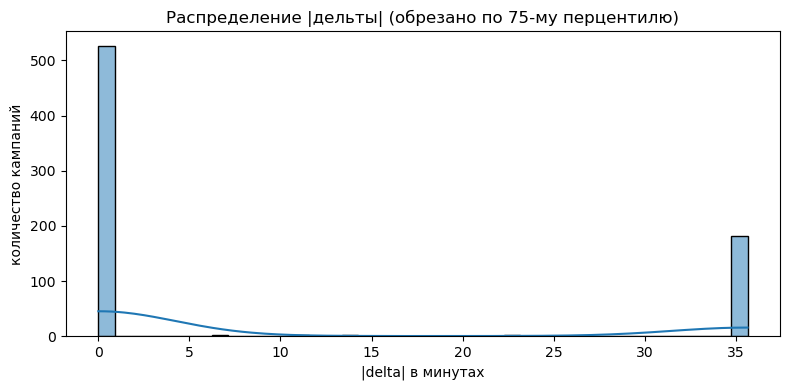

In [70]:
plt.figure(figsize=(8, 4))
sns.histplot(data_core, bins=40, kde=True)
plt.xlabel('|delta| в минутах')
plt.ylabel('количество кампаний')
plt.title('Распределение |дельты| (обрезано по 75-му перцентилю)')
plt.tight_layout()
plt.show()

Возьмём за границу одну минуту, всё что больше по модулю - невалидные сравнение

In [71]:
valid = match[match['abs_delta_min'] <= 1].copy()

In [72]:
print("Сколько кампаний прошло фильтр:", len(valid))
print("Из общего количества:", len(match))
print("Доля корректных совпадений:", round(len(valid) / len(match), 2))

Сколько кампаний прошло фильтр: 526
Из общего количества: 723
Доля корректных совпадений: 0.73


Итого оставили 73% данных

Теперь удалим все невалидные старт-финиш для корректности данных

Ключи валидных финишей (user_id, network, ts)

In [73]:
bq = bqlarge.copy()

In [74]:
valid_keys = set(
    zip(valid['user_id'], valid['network'], valid['event_ts'])
)

маска finish-событий в bqlarge

In [75]:
mask_finish = bq['funnel_step'] == 'finish'

отметим, какой finish валидный

In [76]:
finish_keys_bq = list(
    zip(bqlarge.loc[mask_finish, 'user_id'],
        bqlarge.loc[mask_finish, 'network'],
        bqlarge.loc[mask_finish, 'event_ts'])
)

In [77]:
bq.loc[mask_finish, 'is_valid_finish'] = [
    key in valid_keys for key in finish_keys_bq
]

In [78]:
bq['is_valid_finish'] = bq['is_valid_finish'].fillna(False)

невалидные финиши

In [79]:
mask_invalid_finish = mask_finish & ~bq['is_valid_finish']

проверка

In [80]:
bq.loc[mask_finish, 'is_valid_finish'].value_counts()

is_valid_finish
True     526
False    209
Name: count, dtype: int64

выглядит корректно, идём дальше

Помечаем невалидные финиши в самом датафрейме (для удобства)

In [81]:
bq['is_invalid_finish'] = mask_invalid_finish

индексы невалидных финишей

In [82]:
invalid_fin_idx = bq[bq['is_invalid_finish']].index

Дебаг: посмотрим пары (start, finish) только для первых 10 невалидных финишей

In [83]:
debug_rows = []

for fin_i in invalid_fin_idx[:10]:   # ограничиваемся 10 штуками для просмотра
    fin_row = bq.loc[fin_i]
    uid = fin_row['user_id']
    net = fin_row['network']
    fin_ts = fin_row['event_ts']

    # все события этого user+network
    g = bq[(bq['user_id'] == uid) & (bq['network'] == net)]

    # старты до этого финиша
    starts_before = g[(g['funnel_step'] == 'start') & (g['event_ts'] < fin_ts)]

    if len(starts_before) > 0:
        start_row = starts_before.iloc[-1]  # последний старт перед финишем
        debug_rows.append({
            'user_id': uid,
            'network': net,
            'start_ts': start_row['event_ts'],
            'start_event_name': start_row['event_name'],
            'finish_ts': fin_ts,
            'finish_event_name': fin_row['event_name']
        })
    else:
        debug_rows.append({
            'user_id': uid,
            'network': net,
            'start_ts': None,
            'start_event_name': None,
            'finish_ts': fin_ts,
            'finish_event_name': fin_row['event_name']
        })

In [84]:
debug_df = pd.DataFrame(debug_rows)
debug_df

,user_id,network,start_ts,start_event_name,finish_ts,finish_event_name
0,5019,clickadilla,2025-11-27 10:57:19,create_campaign_1step,2025-11-27 10:58:55,create_campaign
1,8059,clickadilla,2025-12-04 00:02:42,create_campaign_1step,2025-12-04 00:03:53,create_campaign
2,8272,clickadilla,2025-11-21 08:13:10,create_campaign_1step,2025-11-21 08:13:30,create_campaign
3,8272,clickadilla,2025-11-21 08:41:37,create_campaign_1step,2025-11-21 08:43:03,create_campaign
4,8272,clickadilla,2025-11-23 16:06:47,create_campaign_1step,2025-11-23 16:09:39,create_campaign
5,8272,clickadilla,2025-11-23 18:19:54,create_campaign_1step,2025-11-23 18:25:31,create_campaign
6,16609,clickadilla,2025-12-02 03:52:59,create_campaign_1step,2025-12-02 03:57:05,create_campaign
7,16609,clickadilla,2025-12-06 02:22:14,create_campaign_1step,2025-12-06 02:26:26,create_campaign
8,16609,clickadilla,2025-12-06 13:46:03,create_campaign_1step,2025-12-06 13:48:16,create_campaign
9,20336,clickadilla,2025-12-07 11:30:29,create_campaign_1step,2025-12-07 11:31:24,create_campaign


Выглядит корректно, идём дальше

Собираем пары start–finish для всех невалидных финишей

In [85]:
pairs = []

for (uid, net), g in bq.groupby(['user_id', 'network']):
    idx = g.index

    idx_starts = idx[g.loc[idx, 'funnel_step'] == 'start']
    idx_bad_fins = idx[g.loc[idx, 'is_invalid_finish']]

    if len(idx_bad_fins) == 0:
        continue

    for fin_idx in idx_bad_fins:
        fin_row = g.loc[fin_idx]
        fin_ts = fin_row['event_ts']

        # все старты до этого финиша
        starts_before = idx_starts[idx_starts < fin_idx]

        if len(starts_before) > 0:
            start_idx = starts_before.max()
            start_row = g.loc[start_idx]
            pairs.append({
                'user_id': uid,
                'network': net,
                'start_idx': start_idx,
                'start_ts': start_row['event_ts'],
                'finish_idx': fin_idx,
                'finish_ts': fin_ts
            })
        else:
            # финиш без предшествующего старта
            pairs.append({
                'user_id': uid,
                'network': net,
                'start_idx': None,
                'start_ts': None,
                'finish_idx': fin_idx,
                'finish_ts': fin_ts
            })

In [86]:
pairs_df = pd.DataFrame(pairs)
pairs_df.head()

,user_id,network,start_idx,start_ts,finish_idx,finish_ts
0,5019,clickadilla,108.0,2025-11-27 10:57:19,109,2025-11-27 10:58:55
1,8059,clickadilla,178.0,2025-12-04 00:02:42,179,2025-12-04 00:03:53
2,8272,clickadilla,182.0,2025-11-21 08:13:10,183,2025-11-21 08:13:30
3,8272,clickadilla,186.0,2025-11-21 08:41:37,187,2025-11-21 08:43:03
4,8272,clickadilla,188.0,2025-11-23 16:06:47,189,2025-11-23 16:09:39


In [87]:
pairs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     209 non-null    int32         
 1   network     209 non-null    object        
 2   start_idx   208 non-null    float64       
 3   start_ts    208 non-null    datetime64[ns]
 4   finish_idx  209 non-null    int64         
 5   finish_ts   209 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int32(1), int64(1), object(1)
memory usage: 9.1+ KB


In [88]:
pairs_df['has_start'] = pairs_df['start_idx'].notna()
pairs_df['has_start'].value_counts()

has_start
True     208
False      1
Name: count, dtype: int64

Разделим пары «с стартом» и «без старта»

In [89]:
pairs_df['has_start'] = pairs_df['start_idx'].notna()

pairs_with_start = pairs_df[pairs_df['has_start']].copy()
pairs_without_start = pairs_df[~pairs_df['has_start']].copy()

len(pairs_with_start), len(pairs_without_start)

(208, 1)

Соберём индексы, которые нужно удалить

In [90]:
# индексы стартов для пар, где старт есть
to_drop_starts = pairs_with_start['start_idx'].astype(int).tolist()

# индексы финишей для всех невалидных пар (с стартом и без старта)
to_drop_fins = pairs_df['finish_idx'].astype(int).tolist()

# финальный список индексов на удаление
to_drop_idx = sorted(set(to_drop_starts + to_drop_fins))

len(to_drop_starts), len(to_drop_fins), len(to_drop_idx)

(208, 209, 415)

Удаляем строки по индексам

In [91]:
bq_clean = bq.drop(index=to_drop_idx).copy()

In [92]:
len_before = len(bq)
len_after = len(bq_clean)

print("Всего строк было:", len_before)
print("Удалено строк:", len_before - len_after)
print("Осталось строк:", len_after)

print("\nРаспределение воронки до очистки:")
print(bq['funnel_step'].value_counts())

print("\nРаспределение воронки после очистки:")
print(bq_clean['funnel_step'].value_counts())

Всего строк было: 6348
Удалено строк: 415
Осталось строк: 5933

Распределение воронки до очистки:
funnel_step
start     5613
finish     735
Name: count, dtype: int64

Распределение воронки после очистки:
funnel_step
start     5407
finish     526
Name: count, dtype: int64


По факту удалили некорректные записи равномерно как старты создания кампании, так и финиши

In [93]:
bq_clean.head()

,user_id,network,event_ts,event_name,funnel_step,is_valid_finish,is_invalid_finish
1,496,clickadilla,2025-11-21 22:16:37,create_campaign_1step,start,False,False
2,496,clickadilla,2025-11-21 22:17:36,create_campaign,finish,True,False
8,1715,clickadilla,2025-11-17 11:11:02,create_campaign_1step,start,False,False
9,1715,clickadilla,2025-11-17 11:15:03,create_campaign_1step,start,False,False
10,1715,clickadilla,2025-11-18 10:55:08,create_campaign_1step,start,False,False


## DiD анализ (на очищенных данных)

### Обработка данных

Выделим дату

In [94]:
bq_clean['event_date'] = bq_clean['event_ts'].dt.normalize()

In [95]:
bq_clean['event_date'] = pd.to_datetime(bq_clean['event_date'], errors='coerce')

Разметим периоды

In [96]:
last_day = bq_clean['event_date'].max()

post_end   = last_day
post_start = post_end - timedelta(days=6)

test_end   = post_start - timedelta(days=1)
test_start = test_end - timedelta(days=6)

pre_end    = test_start - timedelta(days=1)
pre_start  = pre_end - timedelta(days=6)

In [97]:
periods = {
    'pre':  (pre_start,  pre_end),
    'test': (test_start, test_end),
    'post': (post_start, post_end),
}

In [98]:
def assign_period(d):
    for name, (start, end) in periods.items():
        if start <= d <= end:
            return name
    return None

In [99]:
bq_clean['period'] = bq_clean['event_date'].apply(assign_period)

In [100]:
bq_clean['period'].value_counts(dropna=False)

period
test    2181
post    2023
pre     1729
Name: count, dtype: int64

Довольно ровное распределение

Дневная воронка start → finish по сетям и периодам

In [101]:
daily_funnel = (
    bq_clean
    .groupby(['network', 'event_date', 'period', 'funnel_step'])
    .size()
    .unstack('funnel_step')
    .fillna(0)
    .rename(columns={'start': 'starts', 'finish': 'finishes'})
)

In [102]:
daily_funnel.head()

funnel_step                    finishes  starts
network     event_date period                  
clickadilla 2025-11-17 pre         21.0   276.0
            2025-11-18 pre         21.0   255.0
            2025-11-19 pre         10.0   179.0
            2025-11-20 pre         17.0   198.0
            2025-11-21 pre         30.0   139.0

Добавляем дневную конверсию

In [103]:
daily_funnel['cr'] = np.where(
    daily_funnel['starts'] > 0,
    daily_funnel['finishes'] / daily_funnel['starts'],
    np.nan
)

In [104]:
daily_funnel.reset_index(inplace=True)

In [105]:
daily_funnel.head()

funnel_step,network,event_date,period,finishes,starts,cr
0,clickadilla,2025-11-17,pre,21.0,276.0,0.076087
1,clickadilla,2025-11-18,pre,21.0,255.0,0.082353
2,clickadilla,2025-11-19,pre,10.0,179.0,0.055866
3,clickadilla,2025-11-20,pre,17.0,198.0,0.085859
4,clickadilla,2025-11-21,pre,30.0,139.0,0.215827


### Общие статистики по дневной конверсии

In [106]:
cr_all = daily_funnel['cr'].dropna()

In [107]:
mean_all   = cr_all.mean()
median_all = cr_all.median()
std_all    = cr_all.std(ddof=1)

Доверительный интервал

In [108]:
se_all   = std_all / np.sqrt(n)
ci_low   = mean_all - z * se_all
ci_high  = mean_all + z * se_all

In [110]:
summary_all = {
    'среднее': round(mean_all, 3),
    'медиана': round(median_all, 3),
    'стандартное отклонение': round(std_all, 3),
    'se cr': round(se_all, 3),
    'ci95 low': round(ci_low, 3),
    'ci95 high': round(ci_high, 3)
}

In [111]:
summary_all

{'среднее': 0.284,
 'медиана': 0.195,
 'стандартное отклонение': 0.234,
 'se cr': 0.234,
 'ci95 low': -0.175,
 'ci95 high': 0.743}

### Статистики по периодам и нетворкам

In [116]:
treatment = 'onclicka'
control   = 'clickadilla'

In [117]:
cr_T_pre  = cr_pivot.loc[treatment, 'pre']
cr_T_test = cr_pivot.loc[treatment, 'test']
cr_T_post = cr_pivot.loc[treatment, 'post']

cr_C_pre  = cr_pivot.loc[control, 'pre']
cr_C_test = cr_pivot.loc[control, 'test']
cr_C_post = cr_pivot.loc[control, 'post']

In [118]:
delta_T_test = cr_T_test - cr_T_pre
delta_T_post = cr_T_post - cr_T_pre

delta_C_test = cr_C_test - cr_C_pre
delta_C_post = cr_C_post - cr_C_pre

DiD-эффекты

In [119]:
did_test = (cr_T_test - cr_T_pre) - (cr_C_test - cr_C_pre)
did_post = (cr_T_post - cr_T_pre) - (cr_C_post - cr_C_pre)

In [120]:
did_summary = pd.DataFrame({
    "group": [f"treatment ({treatment})",
              f"control ({control})"],
    "CR_pre":  [cr_T_pre,  cr_C_pre],
    "CR_test": [cr_T_test, cr_C_test],
    "CR_post":[cr_T_post, cr_C_post],
    "Δ_test":  [delta_T_test, delta_C_test],
    "Δ_post":  [delta_T_post, delta_C_post],
})

did_effects = pd.DataFrame({
    "metric": ["did_test", "did_post"],
    "value":  [did_test, did_post],
})

In [121]:
did_summary.round(3)

,group,CR_pre,CR_test,CR_post,Δ_test,Δ_post
0,treatment (onclicka),0.518,0.446,0.493,-0.072,-0.025
1,control (clickadilla),0.097,0.099,0.048,0.002,-0.049


In [122]:
did_effects.round(3)

,metric,value
0,did_test,-0.073
1,did_post,0.024


Видим разные исходные значения метрики на разных нетворках (на Онклике в 5 раз выше!).

Поэтому абсолютный эффект в -7.7 п.п здесь малоинформативен (в тестовый период)

Как и пост эффект (практически нулевой), при том, что на Кликадилле значение метрики ухудшилось в 2 раза, а на Онклике на 10%.

Это наталкивает нас на аналогичный вывод : изначальные значения метрик разные, и контрольная группа не сопоставимо отражает DiD-эффект

__Краткая интерпретация результатов DiD (что показывает таблица)__

1. Каждая группа (тест и контроль) имеет свою конверсию в три периода:

- до теста (pre),
- в тестовую неделю (test),
- после теста (post).

2. Для каждой группы считаем, как изменилась конверсия относительно pre:

Во время теста
$$
\Delta^{g}_{test} = CR_{g,\text{test}} - CR_{g,\text{pre}}
$$
После теста
$$
\Delta^{g}_{post} = CR_{g,\text{post}} - CR_{g,\text{pre}}
$$

3. DiD-эффект показывает, насколько по-разному изменились тест и контроль:

если контроль сильно ухудшился, а тест упал меньше — DiD будет положительным;

если тест ухудшился сильнее, чем контроль — DiD будет отрицательным.

Таблица, которую мы получили, фактически отвечает на три вопроса:

1. Как изменилась конверсия в тесте и в контроле?

Показывают столбцы Δ_test, Δ_post.

2. Какова разница изменений между тестом и контролем?

Показывают строки did_test, did_post.

3. “Выиграл” тест или “проиграл”?

Определяется знаком и величиной Δ:

Δ > 0 → тестовая группа удержалась лучше, чем контроль → потенциальный положительный эффект.

Δ < 0 → тест ухудшился относительно контроля → негативный эффект.

# Кампании на пользователя

Запрос для выборки

In [125]:
query2 = f"""
SELECT
    c.id           AS campaign_id,
    c.user_id,
    c.created_at   AS campaign_created_at,
    an.name        AS ad_network_name
FROM campaigns c
JOIN users u
    ON u.id = c.user_id
LEFT JOIN networks n
    ON n.user_id = u.id
JOIN ad_networks an
    ON an.id = u.ad_network_id
WHERE
    u.email NOT LIKE '%%onlinesup%%'
    AND u.email NOT LIKE '%%tubecorporate%%'

    AND n.user_id IS NULL
AND c.user_id NOT IN (SELECT DISTINCT user_id FROM (
SELECT p.user_id,
SUM(p.amount/10000) AS spend
FROM payments p
WHERE p.type IN ('marketplace', 'campaign')
AND p.created_at BETWEEN '{global_end}' - INTERVAL 30 DAY AND '{global_end}'
GROUP BY user_id
HAVING spend > 5000) AS p)
    AND NOT EXISTS (
        SELECT 1
        FROM campaigns c_api
        WHERE c_api.user_id = u.id
          AND c_api.is_api_created = 1
    )

    AND c.is_api_created = 0

    AND c.created_at >= '{global_start}'
    AND c.created_at <  '{global_end}'

ORDER BY c.user_id DESC, c.created_at DESC
"""

In [126]:
df_all_campaigns = pd.read_sql(query2, engine)

In [127]:
df_all_campaigns.head()

,campaign_id,user_id,campaign_created_at,ad_network_name
0,478557,214003,2025-12-06 22:46:10,Onclicka
1,478551,214003,2025-12-06 21:04:06,Onclicka
2,478550,214003,2025-12-06 20:36:33,Onclicka
3,478473,213982,2025-12-06 11:57:16,Clickadilla
4,478529,213968,2025-12-06 18:22:31,Clickadilla


In [128]:
df_all_campaigns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3986 entries, 0 to 3985
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   campaign_id          3986 non-null   int64         
 1   user_id              3986 non-null   int64         
 2   campaign_created_at  3986 non-null   datetime64[ns]
 3   ad_network_name      3986 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 124.7+ KB


Имеем 3986 созданных кампаний за период

In [129]:
df_all_campaigns['ad_network_name'].value_counts()

ad_network_name
Clickadilla    3354
Onclicka        632
Name: count, dtype: int64

Большинство на Клике

Подготовка данных

In [130]:
df_all_campaigns['campaign_created_at'] = pd.to_datetime(df_all_campaigns['campaign_created_at'])
df_all_campaigns['campaign_date'] = df_all_campaigns['campaign_created_at'].dt.normalize()

In [131]:
df_all_campaigns['period'] = df_all_campaigns['campaign_date'].apply(assign_period)

In [132]:
df_all_campaigns['period'].value_counts(dropna=False)

period
post    1436
test    1424
pre     1126
Name: count, dtype: int64

Видим что кол-во создаваемых кампаний примерно равномерно распределено по периодам

Рассчитаем метрику по дням

In [133]:
daily_cpu = (
    df_all_campaigns
    .groupby(['ad_network_name', 'campaign_date', 'period'], as_index=False)
    .agg(
        total_campaigns=('campaign_id', 'nunique'),
        users=('user_id', 'nunique'),
    )
)

In [134]:
daily_cpu['cpu'] = daily_cpu['total_campaigns'] / daily_cpu['users']

In [135]:
daily_cpu.head()

,ad_network_name,campaign_date,period,total_campaigns,users,cpu
0,Clickadilla,2025-11-17,pre,143,28,5.107143
1,Clickadilla,2025-11-18,pre,164,33,4.969697
2,Clickadilla,2025-11-19,pre,103,34,3.029412
3,Clickadilla,2025-11-20,pre,124,33,3.757576
4,Clickadilla,2025-11-21,pre,83,33,2.515152


## Сводка по всей выборке

In [136]:
cpu_all = daily_cpu['cpu'].dropna()

In [137]:
mean_all   = cpu_all.mean()
median_all = cpu_all.median()
std_all    = cpu_all.std(ddof=1)

In [138]:
se_all  = std_all / np.sqrt(n)
ci_low  = mean_all - z * se_all
ci_high = mean_all + z * se_all

In [139]:
summary_cpu_all = {
    'среднее': round(mean_all, 3),
    'медиана': round(median_all, 3),
    'стандартное отклонение': round(std_all, 3),
    'se cr': round(se_all, 3),
    'ci95 low': round(ci_low, 3),
    'ci95 high': round(ci_high, 3)
}

In [140]:
summary_cpu_all

{'среднее': 3.964,
 'медиана': 2.945,
 'стандартное отклонение': 2.896,
 'se cr': 2.896,
 'ci95 low': -1.712,
 'ci95 high': 9.641}

## DiD по “кампаниям на юзера” для Onclicka vs Clickadilla

In [141]:
cpu_by_net_period = (
    daily_cpu
    .groupby(['ad_network_name', 'period'], as_index=False)['cpu']
    .mean()
)

In [142]:
cpu_pivot = cpu_by_net_period.pivot(
    index='ad_network_name',
    columns='period',
    values='cpu'
)

In [143]:
treatment = 'Onclicka'
control   = 'Clickadilla'

In [144]:
cpu_T_pre  = cpu_pivot.loc[treatment, 'pre']
cpu_T_test = cpu_pivot.loc[treatment, 'test']
cpu_T_post = cpu_pivot.loc[treatment, 'post']

cpu_C_pre  = cpu_pivot.loc[control, 'pre']
cpu_C_test = cpu_pivot.loc[control, 'test']
cpu_C_post = cpu_pivot.loc[control, 'post']

Дельты

In [145]:
delta_T_test = cpu_T_test - cpu_T_pre
delta_T_post = cpu_T_post - cpu_T_pre

delta_C_test = cpu_C_test - cpu_C_pre
delta_C_post = cpu_C_post - cpu_C_pre

DiD эффекты

In [146]:
did_cpu_test = (cpu_T_test - cpu_T_pre) - (cpu_C_test - cpu_C_pre)
did_cpu_post = (cpu_T_post - cpu_T_pre) - (cpu_C_post - cpu_C_pre)

In [147]:
did_cpu_summary = pd.DataFrame({
    "group": [f"treatment ({treatment})",
              f"control ({control})"],
    "CPU_pre":  [cpu_T_pre,  cpu_C_pre],
    "CPU_test": [cpu_T_test, cpu_C_test],
    "CPU_post":[cpu_T_post, cpu_C_post],
    "Δ_test":   [delta_T_test, delta_C_test],
    "Δ_post":   [delta_T_post, delta_C_post],
})

did_cpu_effects = pd.DataFrame({
    "metric": ["did_cpu_test", "did_cpu_post"],
    "value":  [did_cpu_test, did_cpu_post],
})

In [148]:
did_cpu_summary.round(3)

,group,CPU_pre,CPU_test,CPU_post,Δ_test,Δ_post
0,treatment (Onclicka),2.218,2.663,2.179,0.445,-0.039
1,control (Clickadilla),4.232,5.977,6.644,1.745,2.412


In [149]:
did_cpu_effects.round(3)

,metric,value
0,did_cpu_test,-1.300
1,did_cpu_post,-2.451


Так же видим изначально разные уровни по значениям

# Время создания кампании

## Запросы

Выгрузим активных юзеров за период (кто создавал кампании)

In [153]:
query5 = f"""
SELECT
    distinct c.user_id,
    an.name        AS ad_network_name,
    u.created_at as date_reg
FROM campaigns c
JOIN users u
    ON u.id = c.user_id
LEFT JOIN networks n
    ON n.user_id = u.id
JOIN ad_networks an
    ON an.id = u.ad_network_id
WHERE
    u.email NOT LIKE '%%onlinesup%%'
    AND u.email NOT LIKE '%%tubecorporate%%'

    AND n.user_id IS NULL
AND c.user_id NOT IN (SELECT DISTINCT user_id FROM (
SELECT p.user_id,
SUM(p.amount/10000) AS spend
FROM payments p
WHERE p.type IN ('marketplace', 'campaign')
AND p.created_at BETWEEN '{global_end}' - INTERVAL 30 DAY AND '{global_end}'
GROUP BY user_id
HAVING spend > 5000) AS p)
    AND NOT EXISTS (
        SELECT 1
        FROM campaigns c_api
        WHERE c_api.user_id = u.id
          AND c_api.is_api_created = 1
    )

    AND c.is_api_created = 0

    AND c.created_at >= '{global_start}'
    AND c.created_at <  '{global_end}'

ORDER BY u.id
"""

In [154]:
users_df = pd.read_sql(query5, engine)

In [155]:
users_df.head()

,user_id,ad_network_name,date_reg
0,496,Clickadilla,2017-11-07 12:17:25
1,1715,Clickadilla,2018-11-15 15:48:39
2,1965,Clickadilla,2019-02-21 11:02:18
3,1984,Clickadilla,2019-02-25 09:14:24
4,2757,Clickadilla,2019-05-28 09:54:13


In [156]:
users_df['user_group'] = np.where(users_df['date_reg'] > pre_start, 'new', 'old')

In [157]:
users_df.head()

,user_id,ad_network_name,date_reg,user_group
0,496,Clickadilla,2017-11-07 12:17:25,old
1,1715,Clickadilla,2018-11-15 15:48:39,old
2,1965,Clickadilla,2019-02-21 11:02:18,old
3,1984,Clickadilla,2019-02-25 09:14:24,old
4,2757,Clickadilla,2019-05-28 09:54:13,old


Выгрузим ивенты "время создания кампании" из BQ

Запрос в BQ

In [182]:
querybq = '''
WITH onclicka_events AS (
  SELECT
    TIMESTAMP_TRUNC(TIMESTAMP_MICROS(e.event_timestamp), SECOND) AS event_time_sec,
    event_timestamp,
    up.value.int_value AS user_id,
    ep.value.int_value AS event_value_raw,
    'onclicka' AS network,
    FORMAT('%02d:%02d:%02d',
        CAST(FLOOR(CAST(ep.value.int_value / 1000 AS INT64) / 3600) AS INT64),                -- часы
        CAST(FLOOR(MOD(CAST(ep.value.int_value / 1000 AS INT64), 3600) / 60) AS INT64),      -- минуты
        CAST(FLOOR(MOD(CAST(ep.value.int_value / 1000 AS INT64), 60) ) AS INT64)             -- секунды
      ) as time_to_create,
    e.event_name
  FROM `clickadilla.analytics_375634261.events_*` e
  LEFT JOIN UNNEST(e.user_properties) AS up
    ON up.key = 'userId'
  LEFT JOIN UNNEST(e.event_params) AS ep
    ON ep.key = 'event_value'

  WHERE 
    e._TABLE_SUFFIX >= '20251117'
    AND e._TABLE_SUFFIX <=  '20251207'
    AND up.value.int_value IS NOT NULL
    AND e.event_name IN ('time to create campaign')
order by user_id, event_time_sec, event_name
),

clickadilla_events AS (
  SELECT
    TIMESTAMP_TRUNC(TIMESTAMP_MICROS(e.event_timestamp), SECOND) AS event_time_sec,
    event_timestamp,
    up.value.int_value AS user_id,
    ep.value.int_value AS event_value_raw,
    'clickadilla' AS network,
    FORMAT('%02d:%02d:%02d',
        CAST(FLOOR(CAST(ep.value.int_value / 1000 AS INT64) / 3600) AS INT64),                -- часы
        CAST(FLOOR(MOD(CAST(ep.value.int_value / 1000 AS INT64), 3600) / 60) AS INT64),      -- минуты
        CAST(FLOOR(MOD(CAST(ep.value.int_value / 1000 AS INT64), 60) ) AS INT64)             -- секунды
      ) as time_to_create,
    e.event_name
  FROM `clickadilla.analytics_243906903.events_*` e
  LEFT JOIN UNNEST(e.user_properties) AS up
    ON up.key = 'userId'
  LEFT JOIN UNNEST(e.event_params) AS ep
    ON ep.key = 'event_value'

  WHERE 
    e._TABLE_SUFFIX >= '20251117'
    AND e._TABLE_SUFFIX <=  '20251207'
    AND up.value.int_value IS NOT NULL
    AND e.event_name IN ('time_to_create_campaign')
order by user_id, event_time_sec, event_name
)

SELECT
  user_id,
  network,
  event_time_sec,
  event_name,
  time_to_create
FROM onclicka_events

UNION ALL

SELECT
  user_id,
  network,
  event_time_sec,
  event_name,
  time_to_create
FROM clickadilla_events

ORDER BY
  user_id,
  network,
  event_time_sec,
  event_name
'''

In [158]:
bqtimes = pd.read_csv('bqtimes.csv')

In [159]:
bqtimes.head()

,user_id,network,event_time_sec,event_name,time_to_create
0,496,clickadilla,2025-11-21 22:17:36.000000 UTC,time_to_create_campaign,00:00:59
1,1427,clickadilla,2025-12-07 00:33:41.000000 UTC,time_to_create_campaign,00:35:43
2,1715,clickadilla,2025-11-18 10:59:59.000000 UTC,time_to_create_campaign,00:04:52
3,1715,clickadilla,2025-11-24 14:22:42.000000 UTC,time_to_create_campaign,00:06:03
4,1715,clickadilla,2025-11-24 14:35:06.000000 UTC,time_to_create_campaign,00:02:32


## Обработка данных

In [160]:
bqtimes = bqtimes.rename(columns={'event_time_sec':'event_time'})

In [161]:
bqtimes['event_time'] = pd.to_datetime(bqtimes['event_time'], errors='coerce').dt.tz_localize(None)

In [162]:
bqtimes['event_time'] = bqtimes['event_time'].dt.floor('S')

In [163]:
users = users_df['user_id'].to_list()

In [164]:
bqtimes = bqtimes.query('user_id in @users')

In [165]:
bqtimes['user_id'] = bqtimes['user_id'].astype(int)

In [166]:
bqtimes = bqtimes.merge(users_df[['user_id','user_group']], on='user_id', how='left')

In [167]:
bqtimes['event_date'] = bqtimes['event_time'].dt.normalize()

In [168]:
bqtimes['period'] = bqtimes['event_date'].apply(assign_period)

In [169]:
bqtimes['time'] = pd.to_timedelta(bqtimes['time_to_create'])

In [170]:
bqtimes['minutes'] = bqtimes['time'].dt.total_seconds() / 60

In [171]:
bqtimes.head()

,user_id,network,event_time,event_name,time_to_create,user_group,event_date,period,time,minutes
0,496,clickadilla,2025-11-21 22:17:36,time_to_create_campaign,00:00:59,old,2025-11-21,pre,0 days 00:00:59,0.983333
1,1715,clickadilla,2025-11-18 10:59:59,time_to_create_campaign,00:04:52,old,2025-11-18,pre,0 days 00:04:52,4.866667
2,1715,clickadilla,2025-11-24 14:22:42,time_to_create_campaign,00:06:03,old,2025-11-24,test,0 days 00:06:03,6.050000
3,1715,clickadilla,2025-11-24 14:35:06,time_to_create_campaign,00:02:32,old,2025-11-24,test,0 days 00:02:32,2.533333
4,1715,clickadilla,2025-11-24 15:43:39,time_to_create_campaign,00:20:40,old,2025-11-24,test,0 days 00:20:40,20.666667


## Сводка по выборке

In [172]:
n = len(bqtimes)
mean_all   = bqtimes['minutes'].mean()
median_all = bqtimes['minutes'].median()
std_all    = bqtimes['minutes'].std(ddof=1)

In [173]:
se_all   = std_all / np.sqrt(n)
ci_low   = mean_all - z * se_all
ci_high  = mean_all + z * se_all

In [174]:
summary_all = {
    'среднее': round(mean_all, 3),
    'медиана': round(median_all, 3),
    'стандартное отклонение': round(std_all, 3),
    'se cr': round(se_all, 3),
    'ci95 low': round(ci_low, 3),
    'ci95 high': round(ci_high, 3)
}

In [175]:
print('Статистики в минутах')
summary_all

Статистики в минутах


{'среднее': 7.476,
 'медиана': 3.85,
 'стандартное отклонение': 18.868,
 'se cr': 0.603,
 'ci95 low': 6.294,
 'ci95 high': 8.657}

## DiD разрезе юзеров (новый/старый)

### Общие статистики

In [176]:
new_created = bqtimes.query('user_group == "new"')

In [177]:
old_created = bqtimes.query('user_group == "old"')

In [178]:
print('Описательные статистики по времени создания кампании в минутах для новых юзеров')
new_created['minutes'].describe(percentiles=[0.5, 0.75, 0.9]).T.reset_index().round(2)[1:7]

Описательные статистики по времени создания кампании в минутах для новых юзеров


,index,minutes
1,mean,8.12
2,std,12.63
3,min,0.35
4,50%,4.05
5,75%,9.02
6,90%,15.88


In [179]:
print('Описательные статистики по времени создания кампании в минутах для старых юзеров')
old_created['minutes'].describe(percentiles=[0.5, 0.75, 0.9]).T.reset_index().round(2)[1:7]

Описательные статистики по времени создания кампании в минутах для старых юзеров


,index,minutes
1,mean,7.26
2,std,20.52
3,min,0.47
4,50%,3.80
5,75%,6.93
6,90%,13.85


### Новые пользователи

In [200]:
new_pivot = new_created.pivot_table(
    index='network',
    columns='period',
    values='minutes',
    aggfunc = 'mean'
)

In [201]:
treatment = 'onclicka'
control   = 'clickadilla'

In [202]:
T_pre  = new_pivot.loc[treatment, 'pre']
T_test = new_pivot.loc[treatment, 'test']
T_post = new_pivot.loc[treatment, 'post']

C_pre  = new_pivot.loc[control, 'pre']
C_test = new_pivot.loc[control, 'test']
C_post = new_pivot.loc[control, 'post']

In [203]:
delta_T_test = T_test - T_pre
delta_T_post = T_post - T_pre

delta_C_test = C_test - C_pre
delta_C_post = C_post - C_pre

In [204]:
did_test = (T_test - T_pre) - (C_test - C_pre)
did_post = (T_post - T_pre) - (C_post - C_pre)

In [205]:
did_summary = pd.DataFrame({
    "group": [f"treatment ({treatment})",
              f"control ({control})"],
    "avgtime_pre":  [T_pre,  C_pre],
    "avgtime_test": [T_test, C_test],
    "avgtime_post":[T_post, C_post],
    "Δ_test":  [delta_T_test, delta_C_test],
    "Δ_post":  [delta_T_post, delta_C_post],
})

did_effects = pd.DataFrame({
    "metric": ["did_test", "did_post"],
    "value":  [did_test, did_post],
})

In [206]:
did_summary.round(3)

,group,avgtime_pre,avgtime_test,avgtime_post,Δ_test,Δ_post
0,treatment (onclicka),10.492,11.257,10.057,0.765,-0.435
1,control (clickadilla),8.404,6.185,7.200,-2.219,-1.204


In [207]:
did_effects.round(3)

,metric,value
0,did_test,2.984
1,did_post,0.770


### Старые пользователи

In [208]:
old_pivot = old_created.pivot_table(
    index='network',
    columns='period',
    values='minutes',
    aggfunc = 'mean'
)

In [209]:
T_pre  = old_pivot.loc[treatment, 'pre']
T_test = old_pivot.loc[treatment, 'test']
T_post = old_pivot.loc[treatment, 'post']

C_pre  = old_pivot.loc[control, 'pre']
C_test = old_pivot.loc[control, 'test']
C_post = old_pivot.loc[control, 'post']

In [210]:
delta_T_test = T_test - T_pre
delta_T_post = T_post - T_pre

delta_C_test = C_test - C_pre
delta_C_post = C_post - C_pre

In [211]:
did_test = (T_test - T_pre) - (C_test - C_pre)
did_post = (T_post - T_pre) - (C_post - C_pre)

In [212]:
did_summary = pd.DataFrame({
    "group": [f"treatment ({treatment})",
              f"control ({control})"],
    "avgtime_pre":  [T_pre,  C_pre],
    "avgtime_test": [T_test, C_test],
    "avgtime_post":[T_post, C_post],
    "Δ_test":  [delta_T_test, delta_C_test],
    "Δ_post":  [delta_T_post, delta_C_post],
})

did_effects = pd.DataFrame({
    "metric": ["did_test", "did_post"],
    "value":  [did_test, did_post],
})

In [213]:
did_summary.round(3)

,group,avgtime_pre,avgtime_test,avgtime_post,Δ_test,Δ_post
0,treatment (onclicka),6.696,9.566,5.024,2.870,-1.673
1,control (clickadilla),9.760,6.376,5.941,-3.384,-3.819


In [214]:
did_effects.round(3)

,metric,value
0,did_test,6.254
1,did_post,2.146


# Расчёт объёма целевого "флоу" для фичей (изменений)

У нас есть 2 пути пользователя :
    - сначала создаётся кампания, затем реклама
    - или сначала создаётся реклама, и подставляется в кампанию
 
В обоих случаях у нас цель - подстановка креатива в кампанию.

Так как в нашей базе данные более надёжны, попробуем достать эту информацию из базы
Мы будем сравнивать время создания креатива и кампании в рамках одной сессии (30-60 минут), и говорить - если кампания создана раньше, это путь А, если реклама создана раньше - путь Б. 

Случаи, когда кампания не первая и в неё подставляется ранее созданный креатив (используемый в другой кампании юзера) - мы исключаем из анализа как нерелевантные для нас

In [218]:
query3 = f'''
SELECT
    c.id           AS campaign_id,
    c.user_id,
    c.created_at   AS campaign_created_at,
    an.name        AS ad_network_name,
    ads.id AS ad_id,
    ads.created_at AS ad_created_at,
    u.created_at as user_reg
FROM campaigns c
JOIN users u
    ON u.id = c.user_id
LEFT JOIN networks n
    ON n.user_id = u.id
JOIN ad_networks an
    ON an.id = u.ad_network_id
JOIN ads ON ads.id = c.ad_id
WHERE
    u.email NOT LIKE '%%onlinesup%%'
    AND u.email NOT LIKE '%%tubecorporate%%'

    AND n.user_id IS NULL
AND c.user_id NOT IN (SELECT DISTINCT user_id FROM (
SELECT p.user_id,
SUM(p.amount/10000) AS spend
FROM payments p
WHERE p.type IN ('marketplace', 'campaign')
AND p.created_at BETWEEN '{global_end}' - INTERVAL 30 DAY AND '{global_end}'
GROUP BY user_id
HAVING spend > 5000) AS p)
    AND NOT EXISTS (
        SELECT 1
        FROM campaigns c_api
        WHERE c_api.user_id = u.id
          AND c_api.is_api_created = 1
    )

    AND c.is_api_created = 0
    AND c.created_at >= '2025-12-01'
    AND c.created_at <  '2025-12-07'

ORDER BY campaign_id, c.created_at, ads.created_at
'''

In [219]:
ads_df = pd.read_sql(query3, engine)

In [220]:
ads_df.head()

,campaign_id,user_id,campaign_created_at,ad_network_name,ad_id,ad_created_at,user_reg
0,476864,213088,2025-12-01 01:14:04,Clickadilla,447755,2025-12-01 01:13:33,2025-12-01 01:05:38
1,476865,213054,2025-12-01 02:10:43,Onclicka,447756,2025-12-01 02:09:04,2025-11-30 14:02:35
2,476867,91703,2025-12-01 03:40:56,Clickadilla,449173,2025-12-10 19:55:12,2024-05-18 07:57:44
3,476868,91703,2025-12-01 03:48:27,Clickadilla,447759,2025-12-01 03:48:03,2024-05-18 07:57:44
4,476869,213054,2025-12-01 03:50:33,Onclicka,447761,2025-12-01 03:49:27,2025-11-30 14:02:35


Обработка данных

Уберём все записи, где разница между "ивентами" более 60 минут (2 сессии по 30 минут на создание рекламы и креатива)

In [221]:
ads_df['diff_min'] = (
    ads_df['ad_created_at'] - ads_df['campaign_created_at']
).dt.total_seconds() / 60

In [222]:
ads_df['delta_min'] = ads_df['diff_min'].abs()

In [223]:
ads_close = ads_df[ads_df['delta_min'] <= 60].copy()

In [224]:
len_all = len(ads_df)
len_close = len(ads_close)
print(f"Всего строк: {len_all}, осталось после фильтра : {len_close}")

Всего строк: 1436, осталось после фильтра : 542


Удалим повторяющиеся креативы.

Так как если один креатив используется в нескольких кампаниях, мы детектируем только "первый" случай прохода по флоу

In [225]:
ads_close = ads_close.drop_duplicates(subset='ad_id')

Размечаем флоу A / B

- А : кампания → реклама
- Б : реклама → кампания

In [226]:
ads_close['flow'] = np.where(
    ads_close['diff_min'] >= 0,
    'A',
    'B'
)

In [227]:
ads_close['flow'].value_counts()

flow
B    403
A     15
Name: count, dtype: int64

Сразу видим - подавляющее число кампаний создано после реклам

Разметим юзеров на новых и старых

In [228]:
ads_close['user_group'] = np.where(ads_close['user_reg'] > pre_start, 'new', 'old')

In [229]:
ads_close['user_group'].value_counts()

user_group
old    291
new    127
Name: count, dtype: int64

## Саммари

In [230]:
print(f'Всего юзеров за неделю -', ads_close['user_id'].nunique())

Всего юзеров за неделю - 144


In [231]:
print(f'Созданных кампаний за неделю -', ads_close['campaign_id'].nunique())

Созданных кампаний за неделю - 418


In [232]:
def user_flow_group(flows):
    flows_set = set(flows)
    if flows_set == {'A'}:
        return 'only_A'
    elif flows_set == {'B'}:
        return 'only_B'
    else:
        return 'A_and_B'

In [233]:
user_flow = (
    ads_close
    .groupby('user_id')['flow']
    .apply(user_flow_group)
    .reset_index(name='user_flow_group')
)

In [234]:
print('Уникальных юзеров по флоу')
user_flow['user_flow_group'].value_counts()

Уникальных юзеров по флоу


user_flow_group
only_B     134
A_and_B      9
only_A       1
Name: count, dtype: int64

In [235]:
print('Уникальных юзеров по флоу (доли)')
user_flow['user_flow_group'].value_counts(normalize=True).round(2)

Уникальных юзеров по флоу (доли)


user_flow_group
only_B     0.93
A_and_B    0.06
only_A     0.01
Name: proportion, dtype: float64

In [236]:
print('Кампаний по флоу')
ads_close['flow'].value_counts()

Кампаний по флоу


flow
B    403
A     15
Name: count, dtype: int64

In [237]:
print('Кампаний по флоу (доли)')
ads_close['flow'].value_counts(normalize=True).round(2)

Кампаний по флоу (доли)


flow
B    0.96
A    0.04
Name: proportion, dtype: float64

Кажется при таком распределении изучать показатели в разрезах по группам не имеет смысла, можем глазами посмотреть какие юзеры (новые/старые) с каких нетворков идут по пути А и создают вначале кампанию, а затем рекламу

In [238]:
ads_close.query('flow == "A"').groupby(['user_group', 'ad_network_name'])['user_id'].nunique()

user_group  ad_network_name
new         Clickadilla        5
old         Clickadilla        4
            Onclicka           1
Name: user_id, dtype: int64

5 новых пользователей и 5 старых, 9 с Кликадиллы и 1 с Онклики

In [239]:
ads_close.query('flow == "A"')

,campaign_id,user_id,campaign_created_at,ad_network_name,ad_id,ad_created_at,user_reg,diff_min,delta_min,flow,user_group
239,477153,172161,2025-12-01 18:21:14,Onclicka,447900,2025-12-01 18:21:55,2025-02-13 18:51:11,0.683333,0.683333,A,old
504,477466,211993,2025-12-02 12:59:48,Clickadilla,448035,2025-12-02 13:26:05,2025-11-27 10:47:54,26.283333,26.283333,A,new
508,477472,182441,2025-12-02 13:05:57,Clickadilla,448037,2025-12-02 13:27:19,2025-04-14 10:44:27,21.366667,21.366667,A,old
511,477475,182441,2025-12-02 13:17:08,Clickadilla,448039,2025-12-02 13:28:42,2025-04-14 10:44:27,11.566667,11.566667,A,old
841,477904,211653,2025-12-04 15:58:14,Clickadilla,448328,2025-12-04 16:07:34,2025-11-21 14:18:10,9.333333,9.333333,A,new
893,477959,191328,2025-12-04 17:31:42,Clickadilla,448338,2025-12-04 17:44:20,2025-06-12 04:46:45,12.633333,12.633333,A,old
918,477988,213861,2025-12-04 23:00:50,Clickadilla,448351,2025-12-04 23:23:20,2025-12-03 21:24:01,22.500000,22.500000,A,new
1066,478155,186516,2025-12-05 09:31:36,Clickadilla,448410,2025-12-05 09:44:24,2025-05-10 12:22:47,12.800000,12.800000,A,old
1120,478222,211684,2025-12-05 12:57:06,Clickadilla,448452,2025-12-05 13:16:30,2025-11-22 06:53:47,19.400000,19.400000,A,new
1139,478243,213861,2025-12-05 14:18:35,Clickadilla,448471,2025-12-05 14:39:06,2025-12-03 21:24:01,20.516667,20.516667,A,new


Итог : в рамках одной сессии (60 минут) юзеры в подавляющем большинстве случаев предпочитают сначала создавать креатив, а затем создавать рекламную кампанию и подставлять его туда